In [5]:
#Name - Mugdha Kumar
#COURSE - B.TECH IN CSE-2
#COLLEGE - IGDTUW
#ENROLLMENT NO. - 11201012025

In [6]:
#Part - A
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

In [7]:
df = pd.read_csv('/content/agriculture_yield_dataset.csv')
df.head()

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,crop_type,soil_type,yield_ton_per_hectare
0,588.6,18.6,242.4,6.5,6.5,Maize,Loamy,5.92
1,772.8,34.6,247.2,10.0,6.5,Maize,Sandy,6.24
2,970.9,36.3,168.4,7.3,6.4,Wheat,Sandy,4.77
3,611.7,19.0,121.7,3.7,6.0,Maize,Loamy,4.04
4,696.1,29.6,184.6,5.1,6.1,Cotton,Clay,5.17


In [8]:
#Q.1 Dataset Overview
print("Rows and Coloumns = ", df.shape)
print("Coloumn names = ", df.columns.tolist())
print("First ten records = ", df.head(10))

Rows and Coloumns =  (1500, 8)
Coloumn names =  ['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']
First ten records =     rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3     

In [9]:
#Q.2 Data Type and Missing Values
print ("Data Types :\n")
print(df.dtypes)

print("\nMissing Values :\n")
print(df.isnull().sum())

missing_cols=df.columns[df.isnull().sum()>0]
if len(missing_cols)>0:
  print("\nColumns with Missing Values = ")
  print(missing_cols.tolist())
else:
  print("\nNo of Missing Values found = \n", df.isnull().sum())

Data Types :

rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values :

rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

No of Missing Values found = 
 rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [17]:
stats = df.describe()

display(stats)

highest_mean = stats.loc['mean'].idxmax()
highest_std = stats.loc['std'].idxmax()

print("Feature with Highest Mean:", highest_mean)
print("Feature with Highest Standard Deviation:", highest_std)

,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,754.054667,27.749467,148.744067,5.403267,6.759133,5.028793
std,255.097216,5.758101,56.990279,2.584329,0.719742,0.968282
min,300.200000,18.000000,50.300000,1.000000,5.500000,2.090000
25%,536.175000,22.600000,98.600000,3.200000,6.100000,4.337500
50%,761.200000,27.700000,146.850000,5.400000,6.800000,5.010000
75%,964.375000,32.600000,196.575000,7.600000,7.400000,5.740000
max,1200.000000,38.000000,249.900000,10.000000,8.000000,7.860000


Feature with Highest Mean: rainfall_mm
Feature with Highest Standard Deviation: rainfall_mm


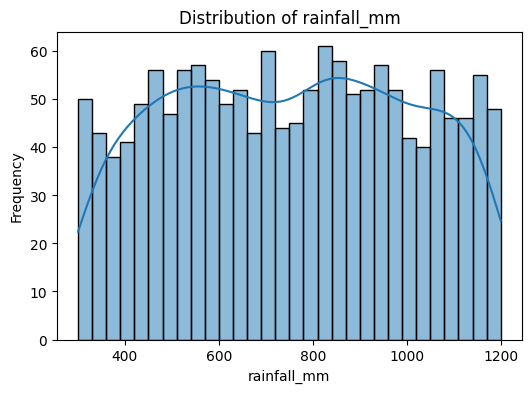

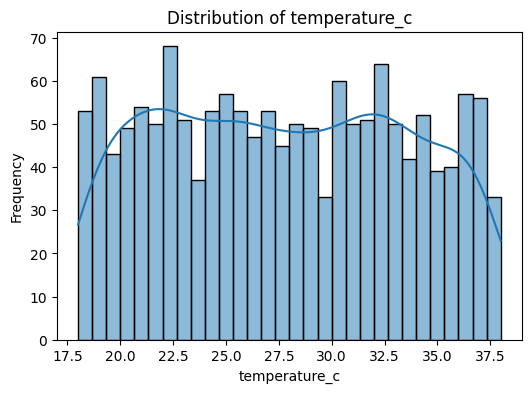

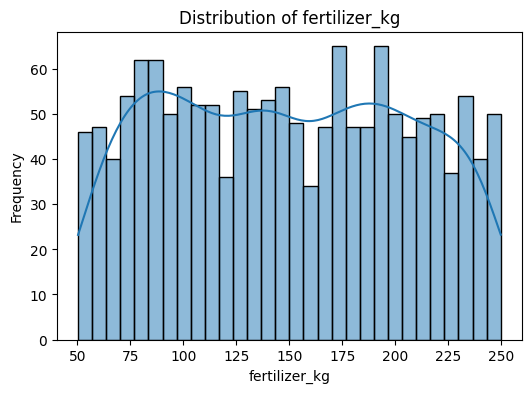

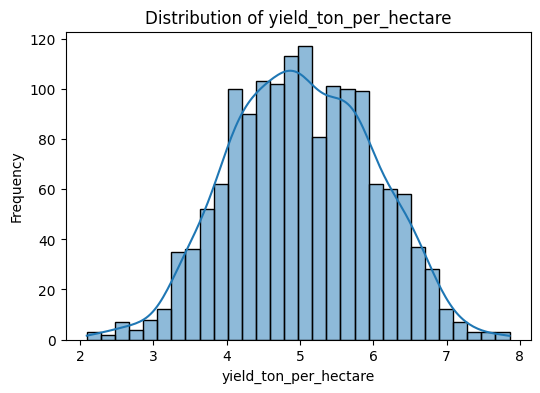

In [10]:
#Part-B
#Q.4 Distrbution Analysis
columns = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]
for col in columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col], bins = 30, kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


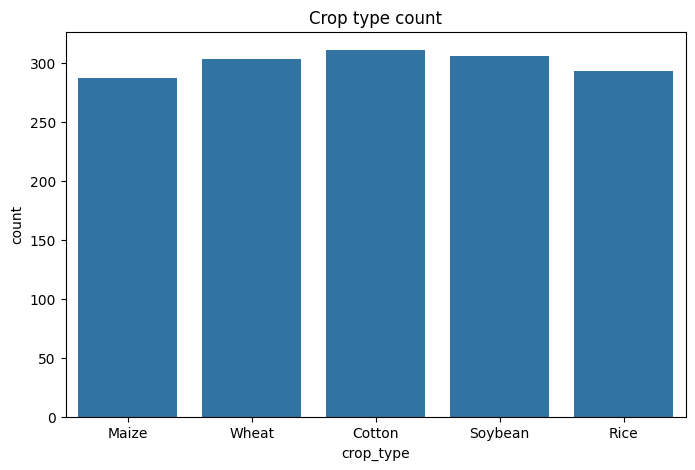


Most Frequent Crop :
Cotton


In [12]:
#Q.5 Crop Type Analysis
crop_counts = df['crop_type'].value_counts()
print(crop_counts)
plt.figure(figsize=(8,5))
sns.countplot(data = df, x='crop_type')
plt.title('Crop type count')
plt.show()
print("\nMost Frequent Crop :")
print(crop_counts.idxmax())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64

Most Common SOil Type:
Clay


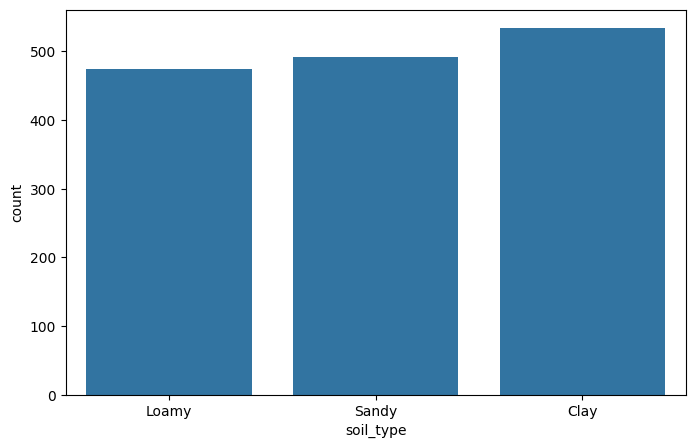

In [14]:
#Q.6 Soil Type Analysis
soil_counts = df['soil_type'].value_counts()
print(soil_counts)
plt.figure(figsize=(8,5))
sns.countplot(data = df, x='soil_type')
print("\nMost Common SOil Type:")
print(soil_counts.idxmax())

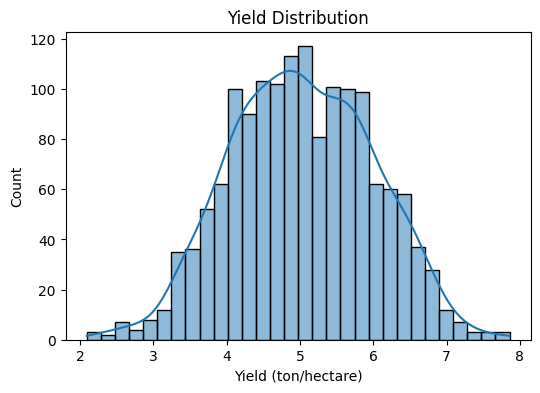

In [18]:
#Q7. Yield Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['yield_ton_per_hectare'], bins=30, kde=True)
plt.title("Yield Distribution")
plt.xlabel("Yield (ton/hectare)")
plt.show()

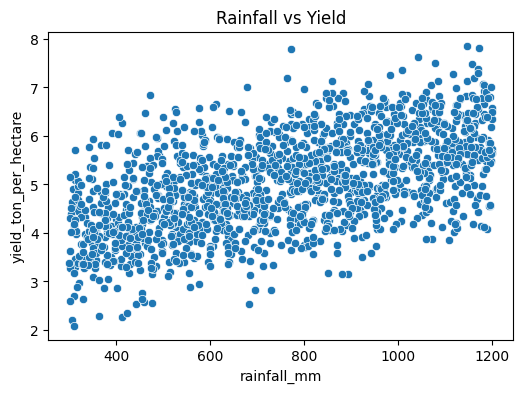

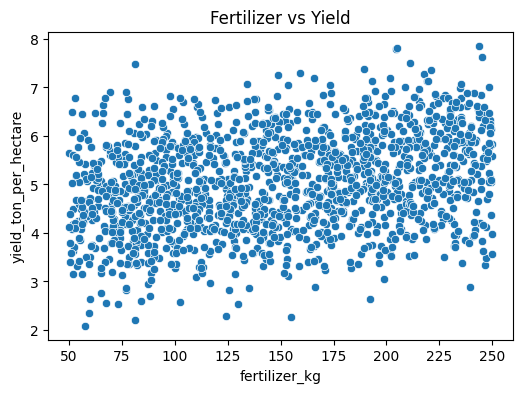

In [19]:
#Q.8 Scatter Plot Analysis
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='rainfall_mm',
    y='yield_ton_per_hectare'
)
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x='fertilizer_kg',
    y='yield_ton_per_hectare'
)
plt.title("Fertilizer vs Yield")
plt.show()

In [ ]:
#Q9. Correlation Analysis
corr_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

yield_corr = corr_matrix['yield_ton_per_hectare'].sort_values(ascending=False)

print("Correlation with Yield:\n")
print(yield_corr)

print("\nTop 3 Features Correlated with Yield:")
print(yield_corr.drop('yield_ton_per_hectare').head(3))

In [20]:
#Q10. Group-Based Analysis
crop_avg_yield = df.groupby(
    'crop_type'
)['yield_ton_per_hectare'].mean()

print("Average Yield by Crop Type:\n")
print(crop_avg_yield)

soil_avg_yield = df.groupby(
    'soil_type'
)['yield_ton_per_hectare'].mean()

print("\nAverage Yield by Soil Type:\n")
print(soil_avg_yield)

print("\nCrop with Highest Average Yield:")
print(crop_avg_yield.idxmax())

print("\nSoil Type with Highest Average Yield:")
print(soil_avg_yield.idxmax())

Average Yield by Crop Type:

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with Highest Average Yield:
Rice

Soil Type with Highest Average Yield:
Loamy


In [21]:
#Part C: Data Preparation
#Q11. Feature Encoding
categorical_columns = df.select_dtypes(
    include='object'
).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns
)

display(df_encoded.head())

Categorical Columns:
['crop_type', 'soil_type']


,rainfall_mm,temperature_c,fertilizer_kg,irrigation_hours,soil_ph,yield_ton_per_hectare,crop_type_Cotton,crop_type_Maize,crop_type_Rice,crop_type_Soybean,crop_type_Wheat,soil_type_Clay,soil_type_Loamy,soil_type_Sandy
0,588.6,18.6,242.4,6.5,6.5,5.92,False,True,False,False,False,False,True,False
1,772.8,34.6,247.2,10.0,6.5,6.24,False,True,False,False,False,False,False,True
2,970.9,36.3,168.4,7.3,6.4,4.77,False,False,False,False,True,False,False,True
3,611.7,19.0,121.7,3.7,6.0,4.04,False,True,False,False,False,False,True,False
4,696.1,29.6,184.6,5.1,6.1,5.17,True,False,False,False,False,True,False,False


In [22]:
#Q12. Feature Selection
X = df_encoded.drop(
    'yield_ton_per_hectare',
    axis=1
)

y = df_encoded['yield_ton_per_hectare']

print("Target Variable:")
print("yield_ton_per_hectare")

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Target Variable:
yield_ton_per_hectare

X Shape: (1500, 13)
y Shape: (1500,)


In [23]:
#Part D: Machine Learning
#Q13. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (1200, 13)
X_test Shape : (300, 13)
y_train Shape: (1200,)
y_test Shape : (300,)


In [24]:
#Q14. Linear Regression Model
model = LinearRegression()

model.fit(X_train, y_train)

print("Intercept:")
print(model.intercept_)

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

display(coefficients)

print(
    "\nFeature with Highest Positive Coefficient:"
)
print(coefficients.iloc[0])

Intercept:
1.9111026182800726


,Feature,Coefficient
7,crop_type_Rice,0.477369
11,soil_type_Loamy,0.365627
3,irrigation_hours,0.198327
8,crop_type_Soybean,0.095096
10,soil_type_Clay,0.062653
2,fertilizer_kg,0.004978
4,soil_ph,0.004901
0,rainfall_mm,0.002035
1,temperature_c,-0.009175
9,crop_type_Wheat,-0.038149



Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.477369
Name: 7, dtype: object
